Labour Market Intelligence Analysis using Python

## Project Overview
## Objective
This project analyzes labour market data using PostgreSQL and Python to identify hiring trends, salary patterns, and in-demand skills for data-related roles.

## Tools
- PostgreSQL
- Python
- Pandas
- Matplotlib

## Import Libraries

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

In [80]:
import psycopg2

## Data Base Connection

In [81]:
import psycopg2
import os

conn = psycopg2.connect(
host=os.getenv("DB_HOST"),
database=os.getenv("DB_NAME"),
user=os.getenv("DB_USER"),
password=os.getenv("DB_PASSWORD"),
port=os.getenv("DB_PORT"),
)

print("Database connected successfully!")

Database connected successfully!


In [82]:
conn

<connection object at 0x0000028B089459C0; dsn: 'user=postgres password=xxx dbname=lmi host=localhost port=5433', closed: 0>

## Load jobs_master from database

In [83]:
df = pd.read_sql(
    "SELECT * FROM jobs_master;",
    conn
)

C:\Users\Halifax\AppData\Local\Temp\ipykernel_34828\2557414867.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


In [84]:
df.head()

,job_id,company_id,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_posted_date,salary_year_avg,company_name,skill_id,skills
0,588486,18710,Data Analyst,Data Analyst Power BI,"Santiago, Chile",via LinkedIn,Full-time,False,2023-05-15 17:54:20,NaN,Soluciones - Data & Analytics Consulting,0.0,sql
1,588486,18710,Data Analyst,Data Analyst Power BI,"Santiago, Chile",via LinkedIn,Full-time,False,2023-05-15 17:54:20,NaN,Soluciones - Data & Analytics Consulting,1.0,python
2,588661,14985,Data Scientist,"Product Development Manager, Data Science","Hyderabad, Telangana, India",via SimplyHired,Full-time,False,2023-06-29 17:13:25,NaN,Epiq,1.0,python
3,588661,14985,Data Scientist,"Product Development Manager, Data Science","Hyderabad, Telangana, India",via SimplyHired,Full-time,False,2023-06-29 17:13:25,NaN,Epiq,4.0,java
4,588661,14985,Data Scientist,"Product Development Manager, Data Science","Hyderabad, Telangana, India",via SimplyHired,Full-time,False,2023-06-29 17:13:25,NaN,Epiq,12.0,bash


In [85]:
df.shape

(3786926, 13)

In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3786926 entries, 0 to 3786925
Data columns (total 13 columns):
 #   Column              Dtype         
---  ------              -----         
 0   job_id              int64         
 1   company_id          int64         
 2   job_title_short     str           
 3   job_title           str           
 4   job_location        str           
 5   job_via             str           
 6   job_schedule_type   str           
 7   job_work_from_home  bool          
 8   job_posted_date     datetime64[us]
 9   salary_year_avg     float64       
 10  company_name        str           
 11  skill_id            float64       
 12  skills              str           
dtypes: bool(1), datetime64[us](1), float64(2), int64(2), str(7)
memory usage: 350.3 MB


In [87]:
df["job_title_short"].value_counts()

job_title_short
Data Engineer                1153596
Data Scientist                828347
Data Analyst                  674114
Senior Data Engineer          318558
Software Engineer             226888
Senior Data Scientist         189449
Business Analyst              145406
Senior Data Analyst           121598
Machine Learning Engineer      79033
Cloud Engineer                 49937
Name: count, dtype: int64

In [88]:
df["skills"].value_counts()

skills
sql            385750
python         381863
aws            145718
azure          132851
r              131285
                ...  
visualbasic         1
dingtalk            1
rocketchat          1
msaccess            1
wimi                1
Name: count, Length: 252, dtype: int64

In [89]:
df.isnull().sum()

job_id                      0
company_id                  0
job_title_short             0
job_title                   1
job_location             5187
job_via                    54
job_schedule_type       52388
job_work_from_home          0
job_posted_date             0
salary_year_avg       3666017
company_name                1
skill_id               117322
skills                 117322
dtype: int64

In [90]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

salary_year_avg       96.807199
skill_id               3.098080
skills                 3.098080
job_schedule_type      1.383391
job_location           0.136971
job_via                0.001426
company_name           0.000026
job_title              0.000026
job_id                 0.000000
company_id             0.000000
job_title_short        0.000000
job_posted_date        0.000000
job_work_from_home     0.000000
dtype: float64

In [91]:
df.duplicated().sum()

np.int64(0)

In [92]:
df.columns.tolist()

['job_id',
 'company_id',
 'job_title_short',
 'job_title',
 'job_location',
 'job_via',
 'job_schedule_type',
 'job_work_from_home',
 'job_posted_date',
 'salary_year_avg',
 'company_name',
 'skill_id',
 'skills']

## Exploratory Data Analysis

1. Data Preparation
2. Job Market Overview
3. Hiring Companies
4. Geographic Distribution
5. In-Demand Skills
6. Skill Salary Analysis
7. Salary Differences Across Roles
8. Remote Work and Salary
9. Key Findings

## 1. Data Preparation

In [93]:
##Salary
# salary_df = df.dropna(subset = ["salary_year_avg"])

In [94]:
#data analyst jobs
data_analyst_df = df[df["job_title_short"] == "Data Analyst"]

In [95]:
#data analyst where salary is not null
da_salary_df = data_analyst_df[data_analyst_df["salary_year_avg"].notna()]

In [96]:
da_salary_df.head()

,job_id,company_id,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,job_posted_date,salary_year_avg,company_name,skill_id,skills
186,747390,21510,Data Analyst,Business Data Analyst II (Tableau),"Dunwoody, GA",via Indeed,Full-time,False,2023-06-28 18:17:58,85000.0,Meridian Cooperative,0.0,sql
1291,1816444,11076,Data Analyst,Data Analyst (Business),"Oakland, CA",via LinkedIn,Full-time,False,2023-04-06 17:00:12,135000.0,Motimatic,0.0,sql
1292,1816444,11076,Data Analyst,Data Analyst (Business),"Oakland, CA",via LinkedIn,Full-time,False,2023-04-06 17:00:12,135000.0,Motimatic,1.0,python
1620,122796,2686,Data Analyst,Marketing Data Analyst,Anywhere,via Get.It,Full-time,True,2023-09-22 09:03:34,84000.0,Get It Recruit - Information Technology,0.0,sql
1621,122796,2686,Data Analyst,Marketing Data Analyst,Anywhere,via Get.It,Full-time,True,2023-09-22 09:03:34,84000.0,Get It Recruit - Information Technology,5.0,r


In [97]:
da_salary_df = da_salary_df[[
    "company_name",
    "job_location",
    "salary_year_avg",
    "skills"]
]

In [98]:
da_salary_df = da_salary_df.sort_values(
    by="salary_year_avg",
    ascending=False
)

In [99]:
    da_salary_df.head()

,company_name,job_location,salary_year_avg,skills
1892228,Mantys,Anywhere,650000.0,NaN
1528283,ЛАНИТ,Belarus,400000.0,git
1477912,ЛАНИТ,Belarus,400000.0,oracle
1494840,ЛАНИТ,Belarus,400000.0,kafka
1504257,ЛАНИТ,Belarus,400000.0,linux


## 2. Overview of the Job Market

In [100]:
job_title_summary = (
    df["job_title_short"]
    .value_counts()
    .reset_index()
)

job_title_summary.columns = [
    "Job Title",
    "Number of Postings"
]

job_title_summary.head(10)

,Job Title,Number of Postings
0,Data Engineer,1153596
1,Data Scientist,828347
2,Data Analyst,674114
3,Senior Data Engineer,318558
4,Software Engineer,226888
5,Senior Data Scientist,189449
6,Business Analyst,145406
7,Senior Data Analyst,121598
8,Machine Learning Engineer,79033
9,Cloud Engineer,49937


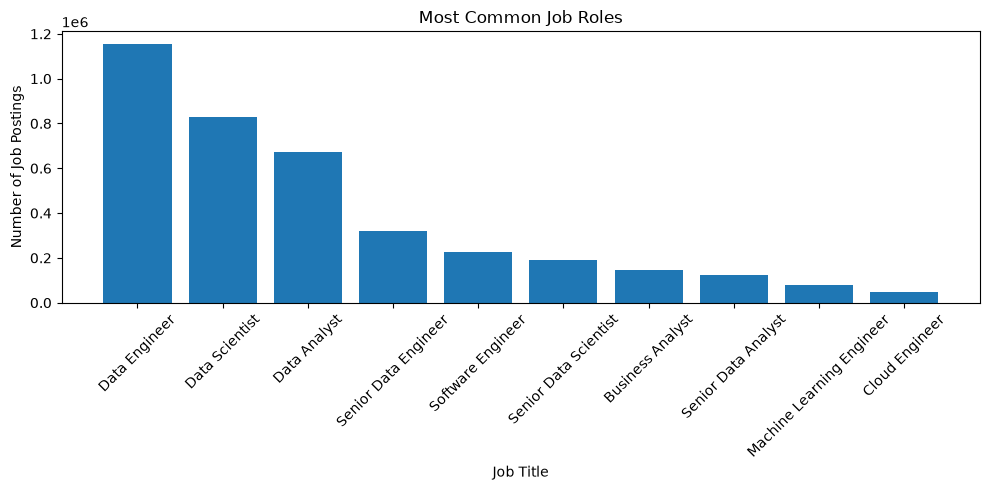

In [101]:
plt.figure(figsize=(10,5))

plt.bar(
    job_title_summary["Job Title"].head(10),
    job_title_summary["Number of Postings"].head(10)
)

plt.title("Most Common Job Roles")
plt.xlabel("Job Title")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Insight

Data Engineer roles represent a significant share of job postings in the dataset, followed by other data-related roles such as Data Scientiest and Data Analyst. This indicates the dataset is highly relevant for analyzing opportunities within the data profession.

## 3. Hiring Companies
Companies with the highest number of job postings

In [102]:
company_summary = (
    df["company_name"]
    .value_counts()
    .head(10)
    .reset_index()
)

company_summary.columns =[
    "Company",
    "Number of Postings"
]

company_summary

,Company,Number of Postings
0,Emprego,29241
1,Capital One,25447
2,Booz Allen Hamilton,23541
3,Dice,14758
4,Walmart,14462
5,Deloitte,12409
6,UnitedHealth Group,11318
7,SynergisticIT,11268
8,Listopro,10806
9,Guidehouse,10605


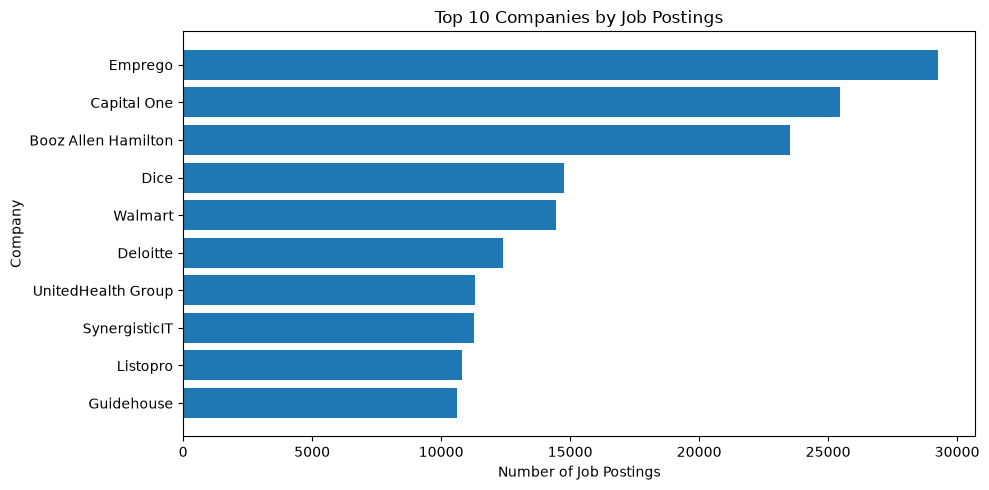

In [103]:
plt.figure(figsize=(10,5))

plt.barh(
    company_summary["Company"],
    company_summary["Number of Postings"]
)

plt.title("Top 10 Companies by Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Insight

Hiring activity is concentrated among a group of employers such as Emprego, Capital One, Booz Allen Hamilton, Dice etc. These companies represent important sources of employment opportunities within the dataset.

## 4. Geographic distribution of jobs
Analyze locations with the highest concentration of job opportunities

In [104]:
location_summary = (
    df["job_location"]
    .value_counts()
    .head(11)
    .reset_index()
    .query("job_location != 'Anywhere'")
)

location_summary.columns = [
    "Location",
    "Number of Postings"
]

location_summary

,Location,Number of Postings
1,Singapore,112378
2,"Bengaluru, Karnataka, India",74735
3,"Paris, France",59180
4,"London, UK",52598
5,"Madrid, Spain",44486
6,"New York, NY",42277
7,United States,41946
8,India,38253
9,"Hyderabad, Telangana, India",37974
10,"Atlanta, GA",37227


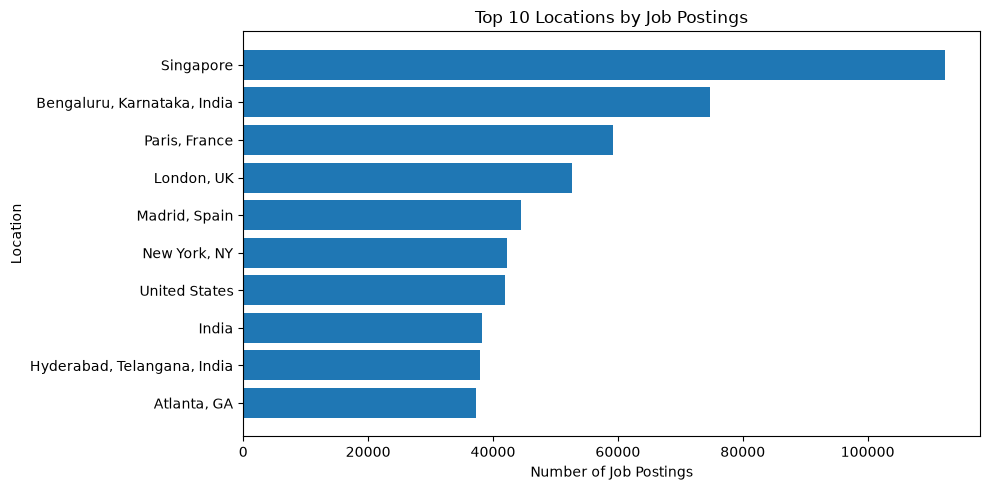

In [105]:
plt.figure(figsize=(10,5))

plt.barh(
    location_summary["Location"],
    location_summary["Number of Postings"]
)

plt.title("Top 10 Locations by Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Location")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Insight

Job postings are concentrated in major global technology and business hubs. Singapore, Bengaluru, Paris, and London account for a large share of opportunities, suggesting strong demand for data-related roles in established technology and financial markets.

## 5. In-Demand Skills
What Skills are most in demand - Skill analysis based on employer demand

In [106]:
skill_demand = (                #type the name of the table you want to create follwed by = and ()
    df["skills"]                ##mention the table you are creating the new table from followed by the column of interest in bracked
    .value_counts()              ##like count(*) in sql
    .head(10)                   ##like limit in sql
    .reset_index()              ## align index with the new column
)

skill_demand.columns = [
    "Skill",
    "Number of Postings"
]

skill_demand

,Skill,Number of Postings
0,sql,385750
1,python,381863
2,aws,145718
3,azure,132851
4,r,131285
5,tableau,127500
6,excel,127341
7,spark,114928
8,power bi,98363
9,java,85854


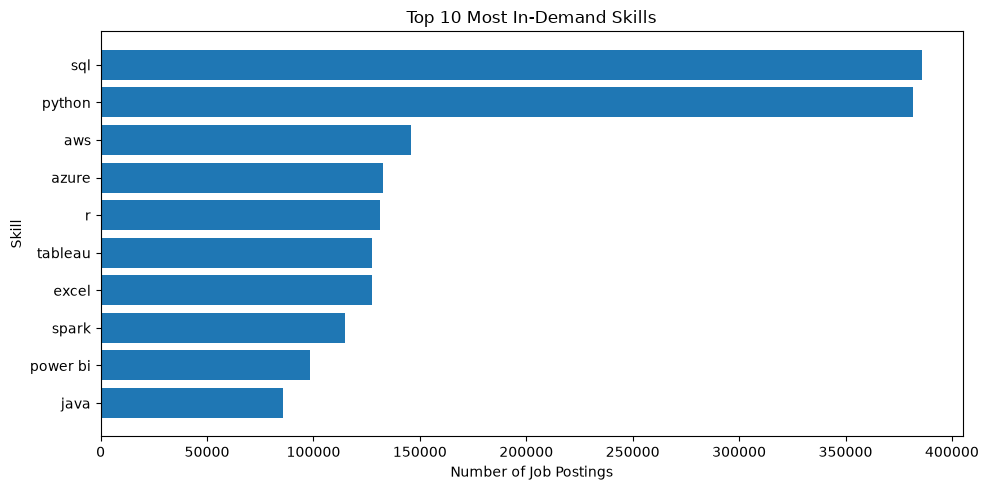

In [107]:
plt.figure(figsize=(10,5))

plt.barh(
    skill_demand["Skill"],
    skill_demand["Number of Postings"]
)

plt.title("Top 10 Most In-Demand Skills")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Insight

Technical skills such as SQL, Python, and data visualization tools are among the most frequently requested skills in job postings. These skills represent core competencies for candidates pursuing data-related roles.

## 6. Skill-Salary Analysis
The skills associated with higher salaries

In [114]:
salary_df = df.dropna(subset = ["salary_year_avg"])

In [115]:
skill_salary = (
    salary_df
    .groupby("skills")["salary_year_avg"]
    .agg(["count", "mean"])
    .reset_index()
)

In [116]:
skill_salary.columns = [
    "Skill",
    "Number of Jobs",
    "Average Salary"
]

In [117]:
skill_salary.head()

,Skill,Number of Jobs,Average Salary
0,airflow,1506,142385.758461
1,airtable,22,140615.340909
2,alteryx,386,112907.287605
3,angular,112,125599.857840
4,angular.js,2,127050.000000


In [133]:
skill_salary = skill_salary.query(
    "`Number of Jobs` >=20"
)

In [134]:
skill_salary.sort_values(
    "Average Salary",
    ascending=False
).head(10)

,Skill,Number of Jobs,Average Salary
109,mongo,262,170714.893130
118,node,65,154408.023077
23,cassandra,530,154124.261055
209,watson,31,152844.225806
154,rshiny,29,151611.150862
82,hugging face,37,148648.175676
114,neo4j,123,147707.930894
161,scala,1912,145119.514885
91,kafka,1642,144753.817210
144,pytorch,1081,144470.137445


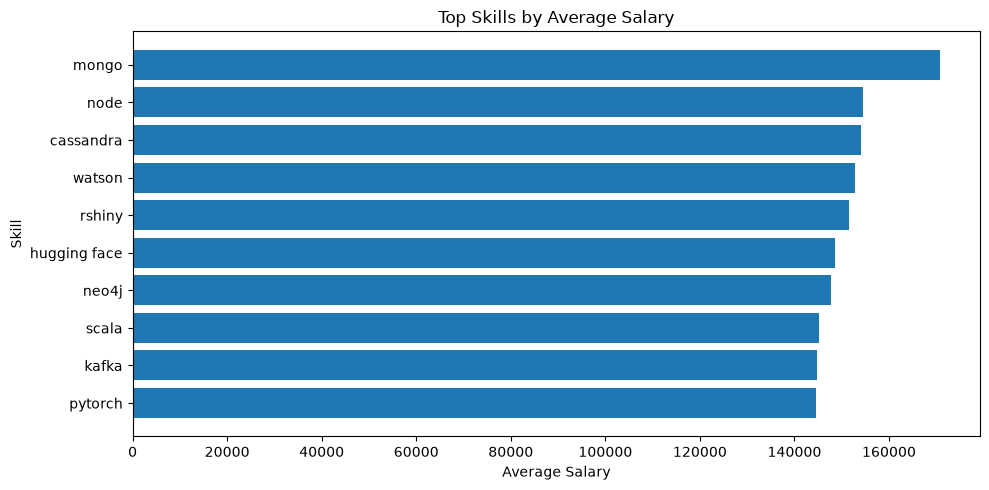

In [135]:
top_salary_skills = (
    skill_salary
    .sort_values(
        "Average Salary",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,5))

plt.barh(
    top_salary_skills["Skill"],
    top_salary_skills["Average Salary"]
)

plt.title("Top Skills by Average Salary")
plt.xlabel("Average Salary")
plt.ylabel("Skill")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Insight

Specialized technical skills tend to be associated with higher average salaries. However, salary rankings should be interpreted alongside demand, since highly specialized skills may appear in fewer job postings.

## 7. Salary Differences Across Roles
 Average salaries across different job titles.

In [136]:
job_salary_summary = (
    salary_df
    .groupby("job_title_short")["salary_year_avg"]
    .agg(["count", "mean"])
    .reset_index()
)

In [137]:
job_salary_summary.columns = [
    "Job Title",
    "Number of Jobs",
    "Average Salary"
]

In [138]:
job_salary_summary

,Job Title,Number of Jobs,Average Salary
0,Business Analyst,2257,95119.390840
1,Cloud Engineer,326,113853.641104
2,Data Analyst,21668,96622.424225
3,Data Engineer,32929,131630.447040
4,Data Scientist,30691,134660.431146
5,Machine Learning Engineer,3120,128490.736218
6,Senior Data Analyst,5142,114653.025147
7,Senior Data Engineer,13056,147864.700590
8,Senior Data Scientist,9019,151756.499097
9,Software Engineer,2701,114186.680416


In [139]:
job_salary_summary = job_salary_summary.query(
    "`Number of Jobs` >= 20"
)

In [140]:
job_salary_summary.sort_values(
    "Average Salary",
    ascending=False
)

,Job Title,Number of Jobs,Average Salary
8,Senior Data Scientist,9019,151756.499097
7,Senior Data Engineer,13056,147864.700590
4,Data Scientist,30691,134660.431146
3,Data Engineer,32929,131630.447040
5,Machine Learning Engineer,3120,128490.736218
6,Senior Data Analyst,5142,114653.025147
9,Software Engineer,2701,114186.680416
1,Cloud Engineer,326,113853.641104
2,Data Analyst,21668,96622.424225
0,Business Analyst,2257,95119.390840


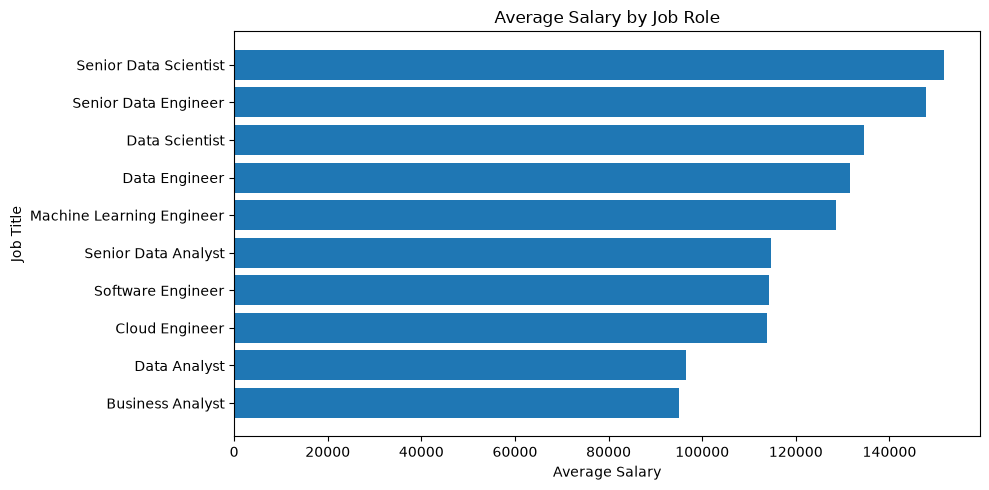

In [141]:
job_salary_plot = (
    job_salary_summary
    .sort_values(
        "Average Salary",
        ascending=False
    )
)

plt.figure(figsize=(10,5))

plt.barh(
    job_salary_plot["Job Title"],
    job_salary_plot["Average Salary"]
)

plt.title("Average Salary by Job Role")
plt.xlabel("Average Salary")
plt.ylabel("Job Title")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Insight

Salary levels vary considerably across data-related roles. Senior Data positions tend to command higher compensation, while analyst roles provide a common entry point into the data profession.

## 8. Remote Work and Remuneration?

Comparison of average salaries between remote and non-remote positions.

In [142]:
remote_salary_summary = (
    salary_df
    .groupby("job_work_from_home")["salary_year_avg"]
    .agg(["count", "mean"])
    .reset_index()
)

In [143]:
remote_salary_summary.columns = [
    "Remote Work",
    "Number of Jobs",
    "Average Salary"
]

In [144]:
remote_salary_summary

,Remote Work,Number of Jobs,Average Salary
0,False,102105,126326.074788
1,True,18804,133603.617805


In [145]:
remote_salary_summary["Remote Work"] = (
    remote_salary_summary["Remote Work"]
    .map({
        True: "Remote",
        False: "Non-Remote"
    })
)

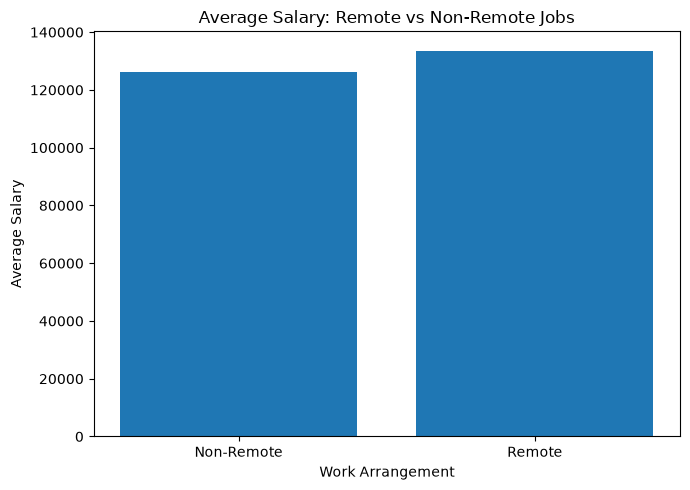

In [146]:
plt.figure(figsize=(7,5))

plt.bar(
    remote_salary_summary["Remote Work"],
    remote_salary_summary["Average Salary"]
)

plt.title("Average Salary: Remote vs Non-Remote Jobs")
plt.xlabel("Work Arrangement")
plt.ylabel("Average Salary")

plt.tight_layout()

plt.show()

### Insight

Remote and non-remote positions show differences in average salary levels. However, salary differences may also reflect differences in job roles, experience requirements, and skill requirements rather than work arrangement alone.

# Key Findings

- Senior Data roles represent a significant portion of the job postings, highlighting strong demand for senior professionals.
- SQL is among the most frequently requested skills, confirming its importance as a foundational skill for data roles.
- Technical and specialized skills are associated with differences in salary outcomes across the labour market.
- Salary levels vary across data-related career paths, with more specialized roles generally commanding higher compensation.
- Remote opportunities represent an important part of the current labour market.